# 03 — Data Mining Techniques & Model Evaluation
**CMPE 255 — Student Dropout Prediction Project**

This notebook covers:
- Classification: Decision Tree, Random Forest, KNN, Logistic Regression, SVM, XGBoost
- Clustering: K-Means, Hierarchical
- Association Rules: Apriori (optional)
- Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrices
- Model comparison table
- Feature importance analysis

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, silhouette_score
)
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize
from scipy.cluster.hierarchy import dendrogram, linkage
from xgboost import XGBClassifier
import os

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/tables', exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

TARGET_NAMES = ['Dropout', 'Enrolled', 'Graduate']
COLORS = {'Dropout': '#E24B4A', 'Enrolled': '#EF9F27', 'Graduate': '#1D9E75'}

# Import helper functions from src/
sys.path.insert(0, '../src')
from utils import plot_roc_multiclass, build_comparison_table

# Load preprocessed data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

# Full scaled dataset for cross-validation (fit on entire dataset in notebook 01)
try:
    X_scaled_full = pd.read_csv('../data/X_scaled_full.csv')
    y_full        = pd.read_csv('../data/y_full.csv').squeeze()
except FileNotFoundError:
    X_scaled_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
    y_full        = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

# Results dictionary — populated by each model block
results = {}

print(f'Training : {X_train.shape}  |  Test: {X_test.shape}')
print(f'Full (CV): {X_scaled_full.shape}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  Fi

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  Fi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Training : (3539, 36)  |  Test: (885, 36)
Full (CV): (4424, 36)


---
## Part A: Classification (30 pts section)
### Model 1: Decision Tree

              precision    recall  f1-score   support

     Dropout       0.72      0.65      0.69       284
    Enrolled       0.41      0.36      0.39       159
    Graduate       0.79      0.88      0.83       442

    accuracy                           0.71       885
   macro avg       0.64      0.63      0.63       885
weighted avg       0.70      0.71      0.71       885



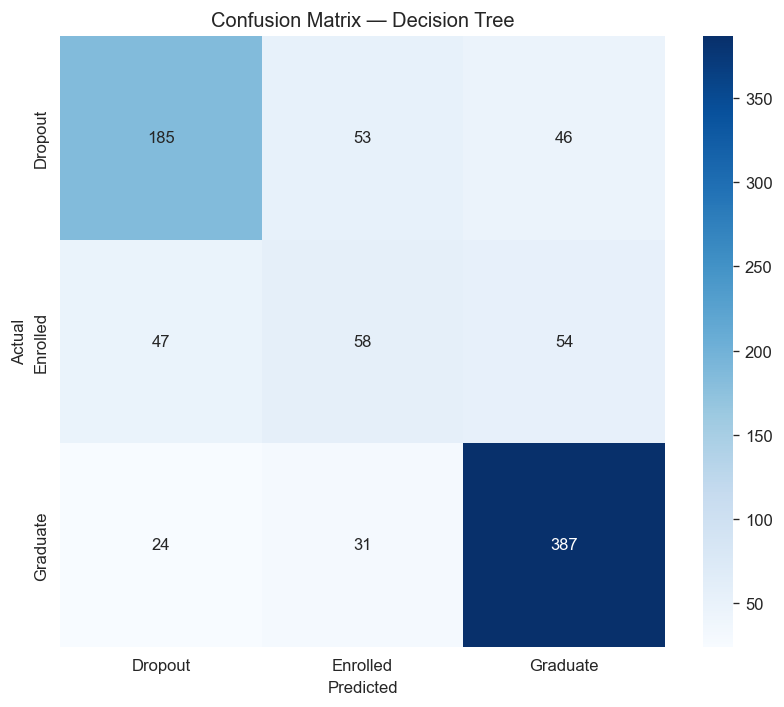

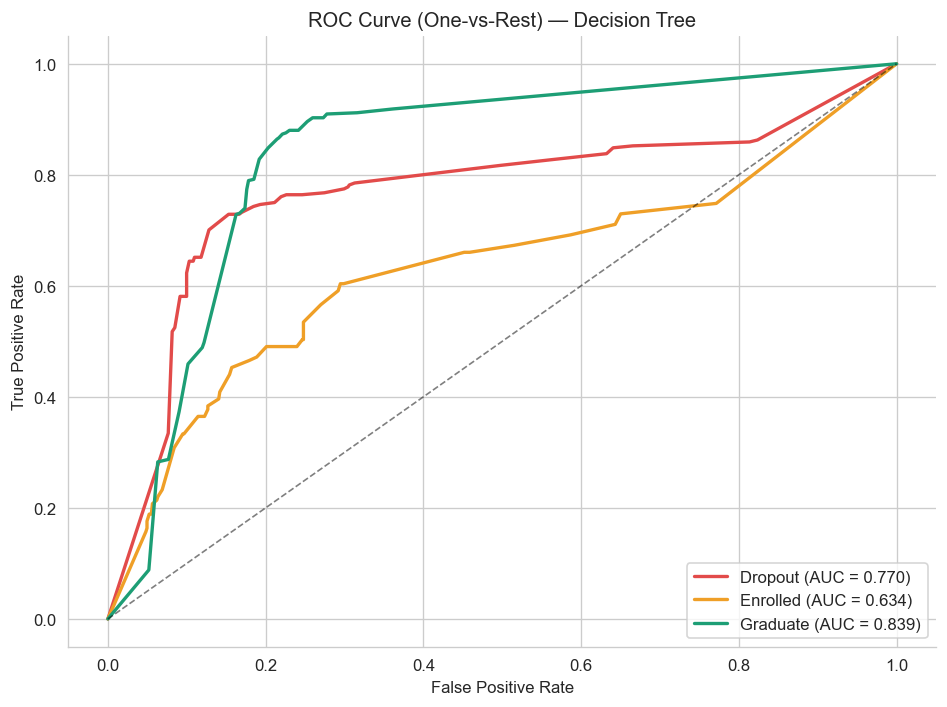

5-Fold CV F1 (macro): 0.6443 ± 0.0101


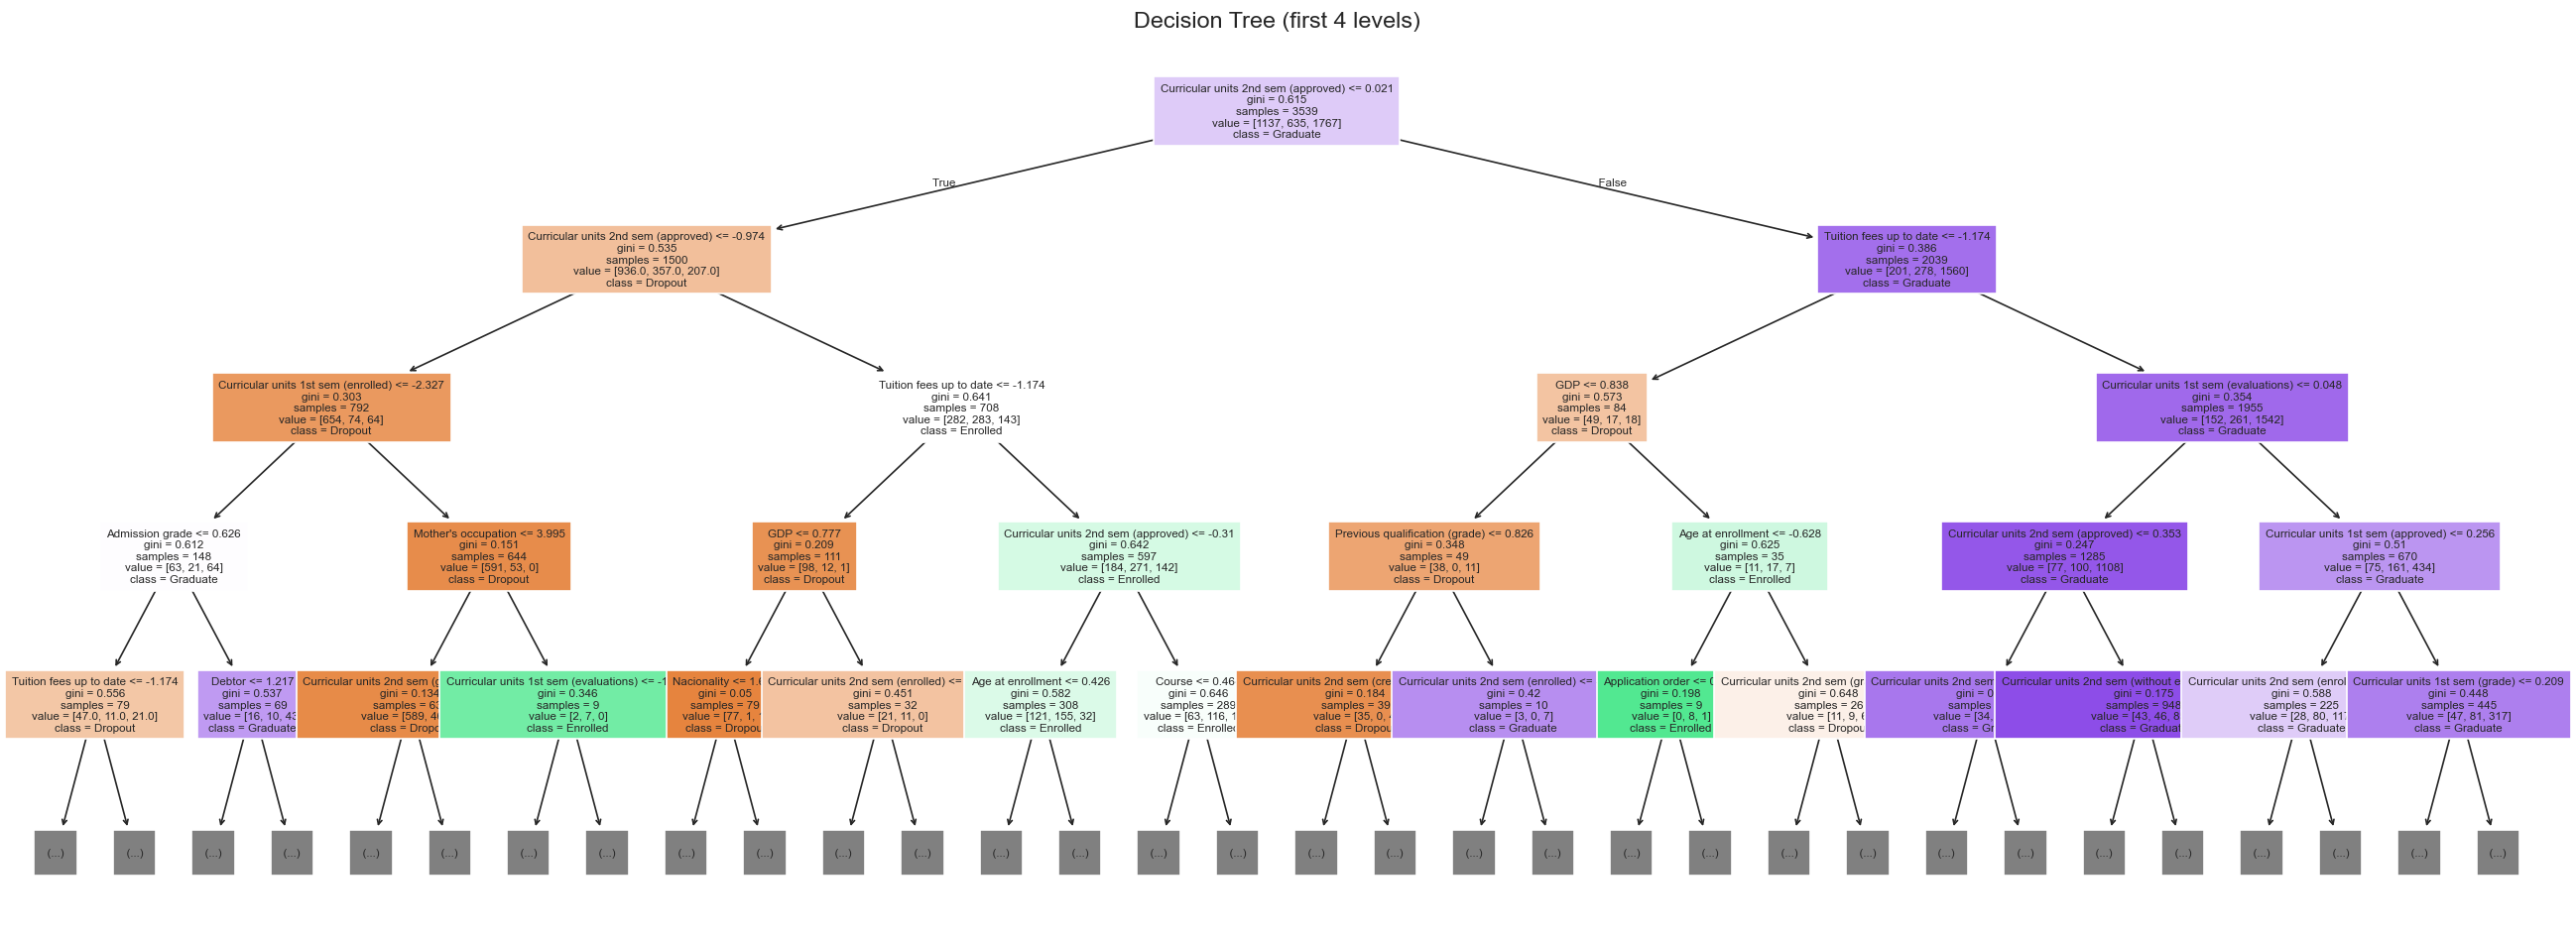

In [2]:
# ── Model 1: Decision Tree ──────────────────────────────────────────────────
model_name = 'Decision Tree'

dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)

print(classification_report(y_test, y_pred_dt, target_names=TARGET_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {model_name}')
plt.tight_layout()
fig.savefig('../results/figures/dt_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve (One-vs-Rest)
y_test_str = [TARGET_NAMES[i] for i in y_test]
plot_roc_multiclass(y_test_str, y_prob_dt, model_name=model_name,
                    save_path='../results/figures/dt_roc.png')

# 5-Fold Cross-validation
cv_dt = cross_val_score(dt, X_scaled_full, y_full, cv=5, scoring='f1_macro')
print(f'5-Fold CV F1 (macro): {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')

results[model_name] = {
    'accuracy':     accuracy_score(y_test, y_pred_dt),
    'f1_macro':     f1_score(y_test, y_pred_dt, average='macro'),
    'f1_weighted':  f1_score(y_test, y_pred_dt, average='weighted'),
    'cv_f1_mean':   cv_dt.mean(),
    'cv_f1_std':    cv_dt.std(),
}

# Visualize tree — first 4 levels
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(dt, max_depth=4, feature_names=X_train.columns.tolist(),
          class_names=TARGET_NAMES, filled=True, ax=ax, fontsize=7)
ax.set_title('Decision Tree (first 4 levels)', fontsize=14)
plt.tight_layout()
fig.savefig('../results/figures/dt_tree.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 2: Random Forest

              precision    recall  f1-score   support

     Dropout       0.80      0.76      0.78       284
    Enrolled       0.57      0.35      0.43       159
    Graduate       0.79      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.75       885



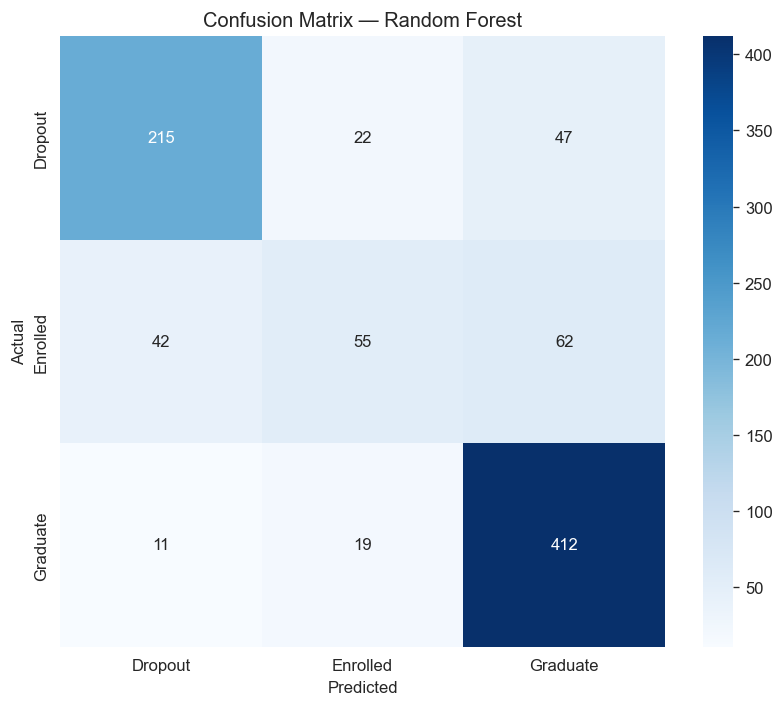

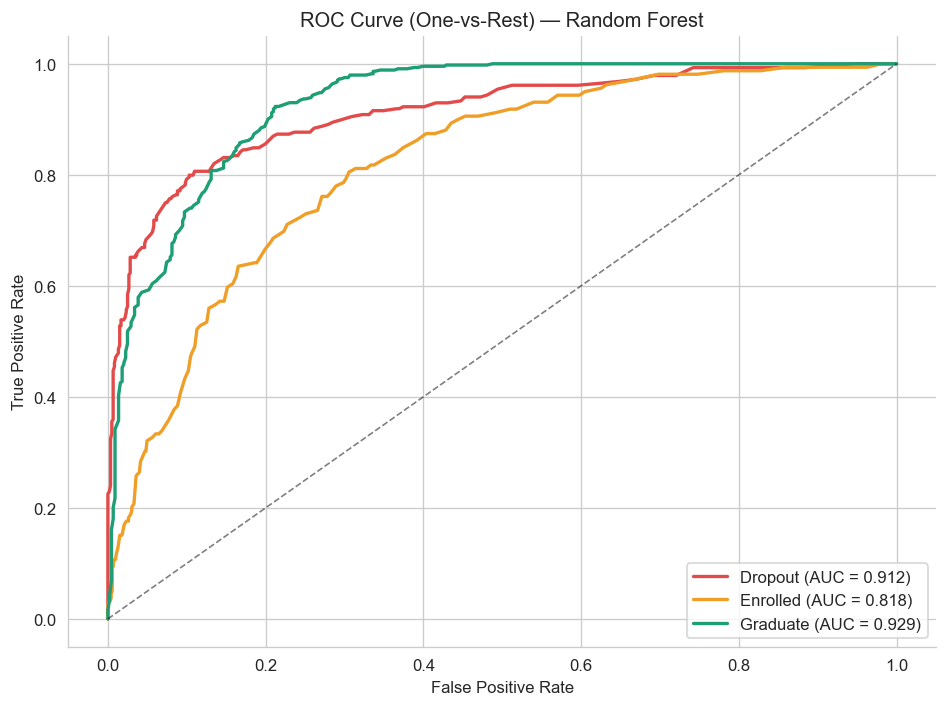

5-Fold CV F1 (macro): 0.6956 ± 0.0087


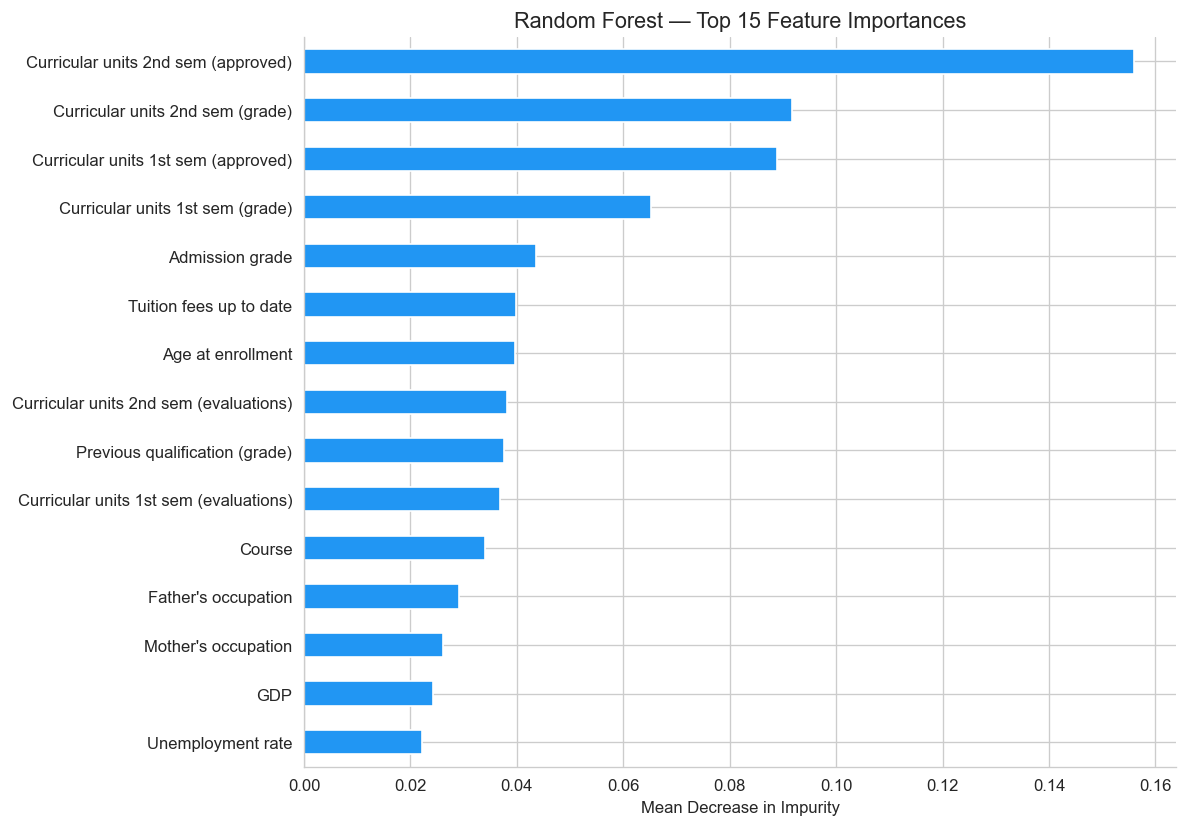

In [3]:
# ── Model 2: Random Forest ──────────────────────────────────────────────────
model_name = 'Random Forest'

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

print(classification_report(y_test, y_pred_rf, target_names=TARGET_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {model_name}')
plt.tight_layout()
fig.savefig('../results/figures/rf_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
y_test_str = [TARGET_NAMES[i] for i in y_test]
plot_roc_multiclass(y_test_str, y_prob_rf, model_name=model_name,
                    save_path='../results/figures/rf_roc.png')

# 5-Fold CV
cv_rf = cross_val_score(rf, X_scaled_full, y_full, cv=5, scoring='f1_macro')
print(f'5-Fold CV F1 (macro): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

results[model_name] = {
    'accuracy':     accuracy_score(y_test, y_pred_rf),
    'f1_macro':     f1_score(y_test, y_pred_rf, average='macro'),
    'f1_weighted':  f1_score(y_test, y_pred_rf, average='weighted'),
    'cv_f1_mean':   cv_rf.mean(),
    'cv_f1_std':    cv_rf.std(),
}

# Feature importance — top 15 (horizontal bar chart)
feat_imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
feat_imp_rf.tail(15).plot.barh(ax=ax, color='#2196F3')
ax.set_title('Random Forest — Top 15 Feature Importances', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('../results/figures/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Model 3: K-Nearest Neighbors

k= 3: accuracy=0.6644
k= 5: accuracy=0.6667
k= 7: accuracy=0.6757
k= 9: accuracy=0.6915
k=11: accuracy=0.6949

Best k: 11  (accuracy=0.6949)


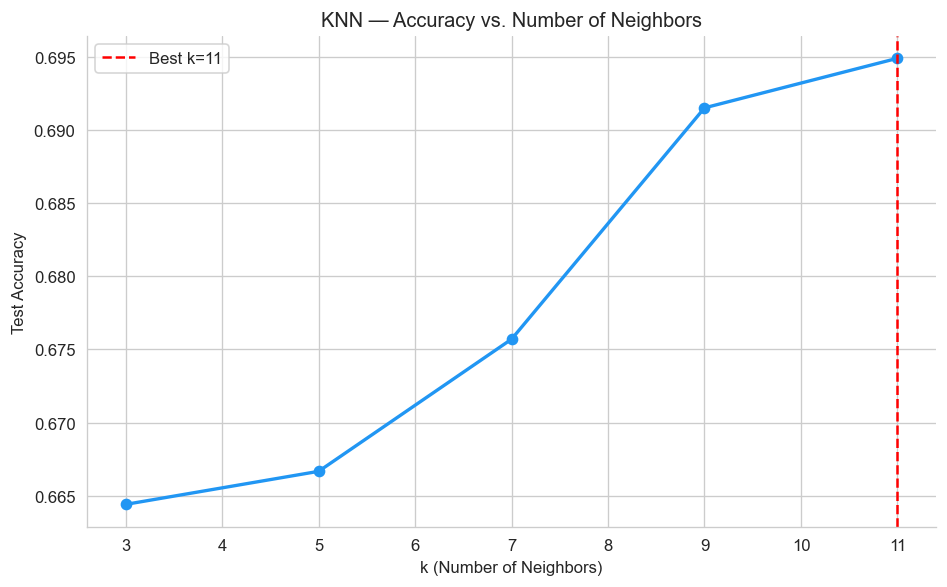

              precision    recall  f1-score   support

     Dropout       0.77      0.65      0.71       284
    Enrolled       0.38      0.19      0.26       159
    Graduate       0.71      0.90      0.79       442

    accuracy                           0.69       885
   macro avg       0.62      0.58      0.59       885
weighted avg       0.67      0.69      0.67       885



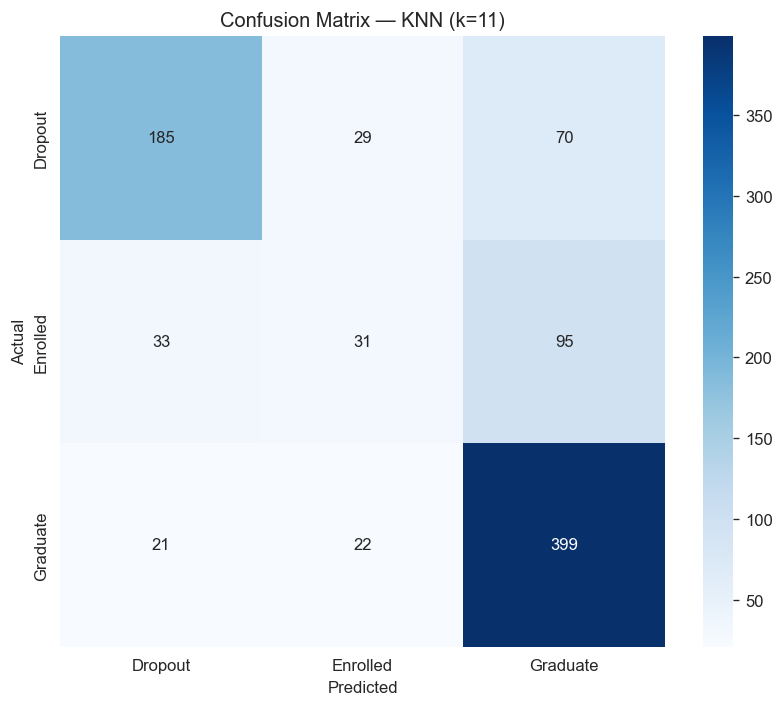

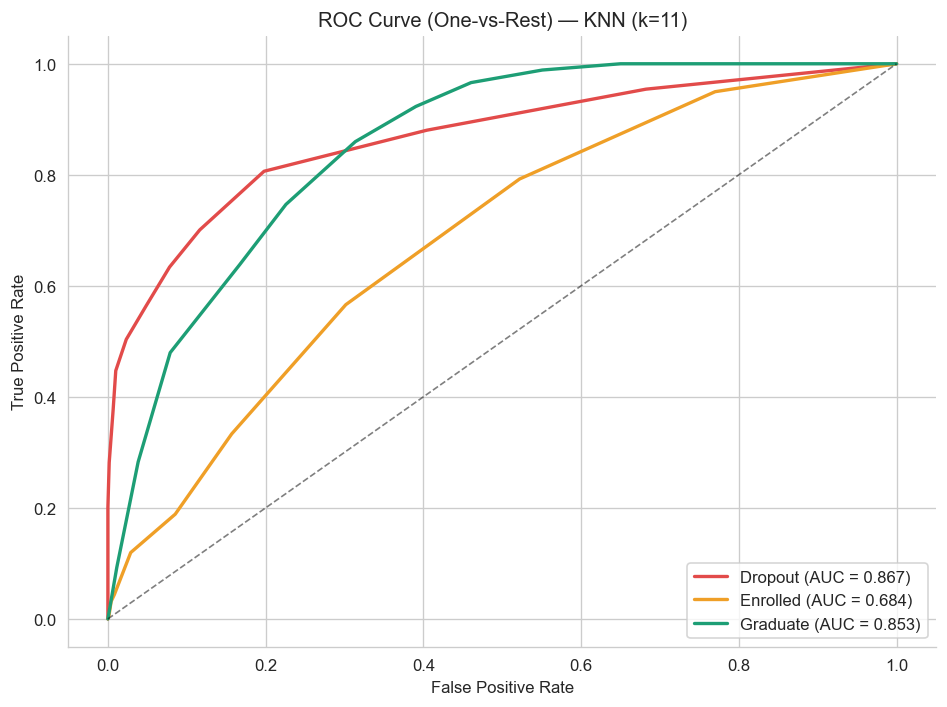

5-Fold CV F1 (macro): 0.6036 ± 0.0094


In [4]:
# ── Model 3: K-Nearest Neighbors ────────────────────────────────────────────
# Step 1: Find optimal k by testing k = 3, 5, 7, 9, 11
k_values = [3, 5, 7, 9, 11]
k_accuracies = []
for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_tmp.predict(X_test))
    k_accuracies.append(acc)
    print(f'k={k:2d}: accuracy={acc:.4f}')

best_k = k_values[int(np.argmax(k_accuracies))]
print(f'\nBest k: {best_k}  (accuracy={max(k_accuracies):.4f})')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, k_accuracies, marker='o', linewidth=2, color='#2196F3')
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('k (Number of Neighbors)')
ax.set_ylabel('Test Accuracy')
ax.set_title('KNN — Accuracy vs. Number of Neighbors')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('../results/figures/knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 2: Final model with best k
model_name = 'KNN'
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)

print(classification_report(y_test, y_pred_knn, target_names=TARGET_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — KNN (k={best_k})')
plt.tight_layout()
fig.savefig('../results/figures/knn_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
y_test_str = [TARGET_NAMES[i] for i in y_test]
plot_roc_multiclass(y_test_str, y_prob_knn, model_name=f'KNN (k={best_k})',
                    save_path='../results/figures/knn_roc.png')

# 5-Fold CV
cv_knn = cross_val_score(knn, X_scaled_full, y_full, cv=5, scoring='f1_macro')
print(f'5-Fold CV F1 (macro): {cv_knn.mean():.4f} ± {cv_knn.std():.4f}')

results[model_name] = {
    'accuracy':     accuracy_score(y_test, y_pred_knn),
    'f1_macro':     f1_score(y_test, y_pred_knn, average='macro'),
    'f1_weighted':  f1_score(y_test, y_pred_knn, average='weighted'),
    'cv_f1_mean':   cv_knn.mean(),
    'cv_f1_std':    cv_knn.std(),
}

### Model 4: Logistic Regression

              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.52      0.33      0.41       159
    Graduate       0.80      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885



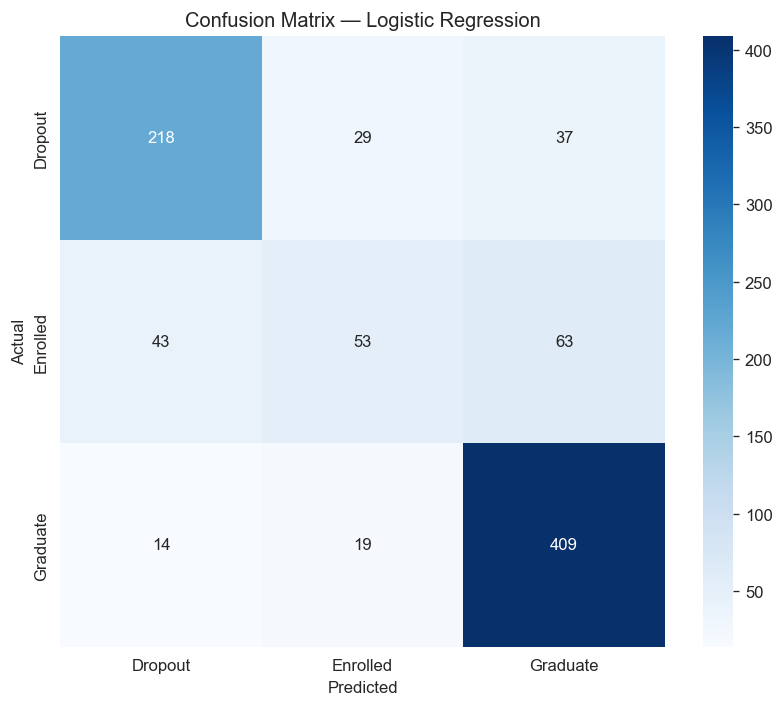

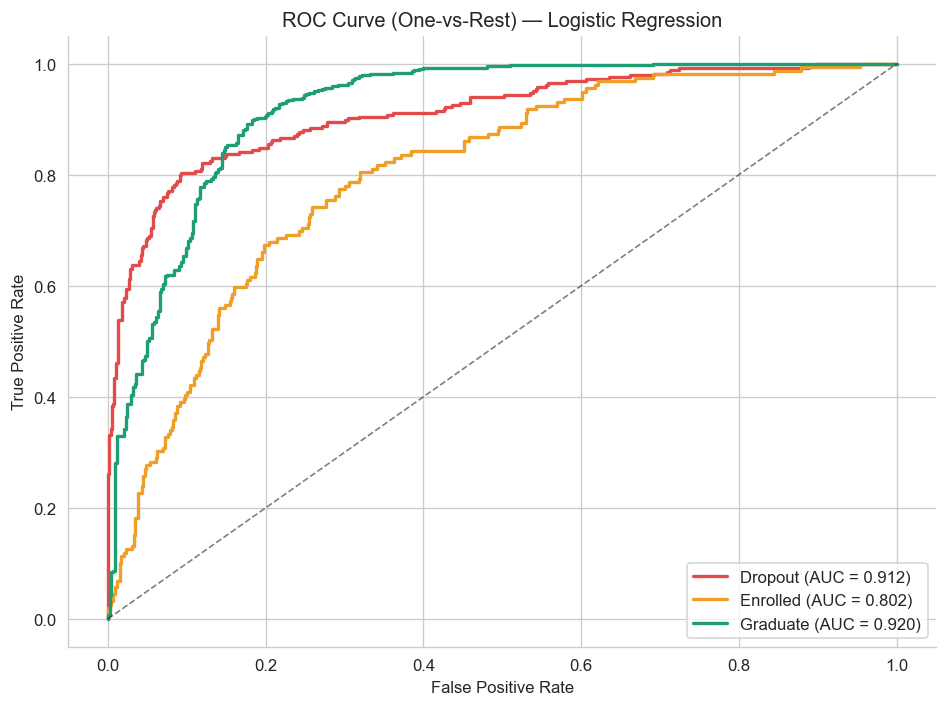

5-Fold CV F1 (macro): 0.6782 ± 0.0089


In [5]:
# ── Model 4: Logistic Regression ────────────────────────────────────────────
model_name = 'Logistic Regression'

lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)

print(classification_report(y_test, y_pred_lr, target_names=TARGET_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {model_name}')
plt.tight_layout()
fig.savefig('../results/figures/lr_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
y_test_str = [TARGET_NAMES[i] for i in y_test]
plot_roc_multiclass(y_test_str, y_prob_lr, model_name=model_name,
                    save_path='../results/figures/lr_roc.png')

# 5-Fold CV
cv_lr = cross_val_score(lr, X_scaled_full, y_full, cv=5, scoring='f1_macro')
print(f'5-Fold CV F1 (macro): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

results[model_name] = {
    'accuracy':     accuracy_score(y_test, y_pred_lr),
    'f1_macro':     f1_score(y_test, y_pred_lr, average='macro'),
    'f1_weighted':  f1_score(y_test, y_pred_lr, average='weighted'),
    'cv_f1_mean':   cv_lr.mean(),
    'cv_f1_std':    cv_lr.std(),
}

### Model 5: Support Vector Machine

              precision    recall  f1-score   support

     Dropout       0.84      0.73      0.78       284
    Enrolled       0.50      0.35      0.41       159
    Graduate       0.77      0.93      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



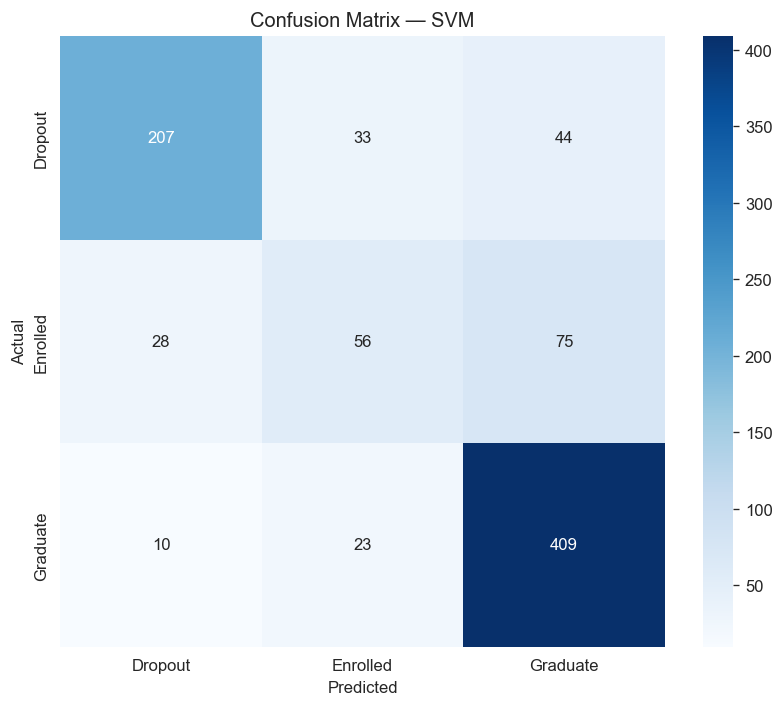

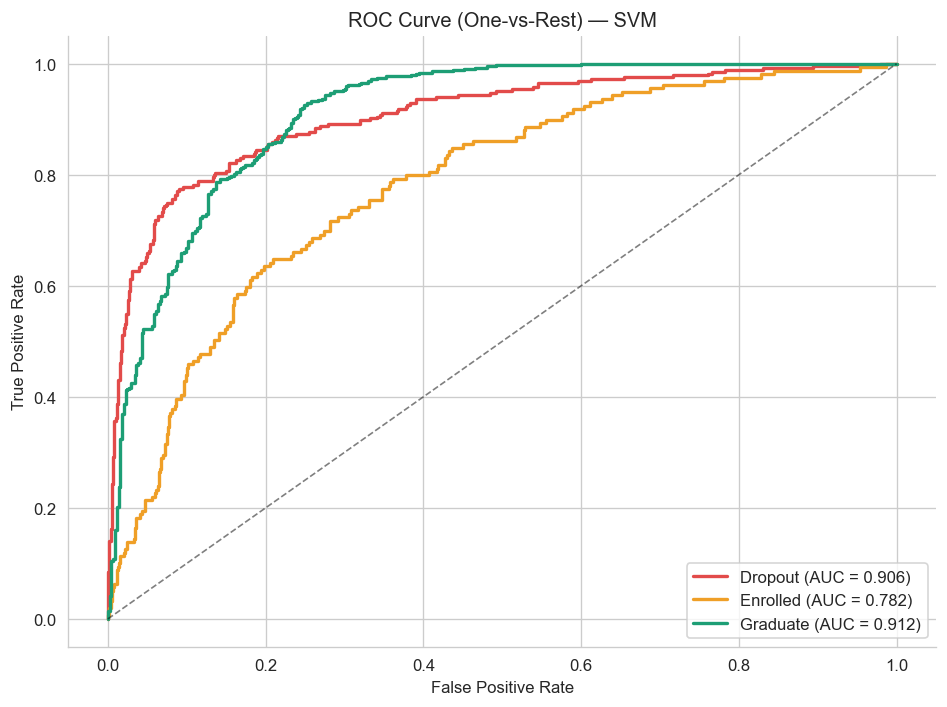

5-Fold CV F1 (macro): 0.6798 ± 0.0220


In [6]:
# ── Model 5: Support Vector Machine ─────────────────────────────────────────
model_name = 'SVM'

svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)

print(classification_report(y_test, y_pred_svm, target_names=TARGET_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {model_name}')
plt.tight_layout()
fig.savefig('../results/figures/svm_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
y_test_str = [TARGET_NAMES[i] for i in y_test]
plot_roc_multiclass(y_test_str, y_prob_svm, model_name=model_name,
                    save_path='../results/figures/svm_roc.png')

# 5-Fold CV (SVM can be slow on full dataset)
cv_svm = cross_val_score(svm, X_scaled_full, y_full, cv=5, scoring='f1_macro')
print(f'5-Fold CV F1 (macro): {cv_svm.mean():.4f} ± {cv_svm.std():.4f}')

results[model_name] = {
    'accuracy':     accuracy_score(y_test, y_pred_svm),
    'f1_macro':     f1_score(y_test, y_pred_svm, average='macro'),
    'f1_weighted':  f1_score(y_test, y_pred_svm, average='weighted'),
    'cv_f1_mean':   cv_svm.mean(),
    'cv_f1_std':    cv_svm.std(),
}

### Model 6: Gradient Boosting / XGBoost

              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.53      0.45      0.48       159
    Graduate       0.82      0.90      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.71       885
weighted avg       0.76      0.77      0.76       885



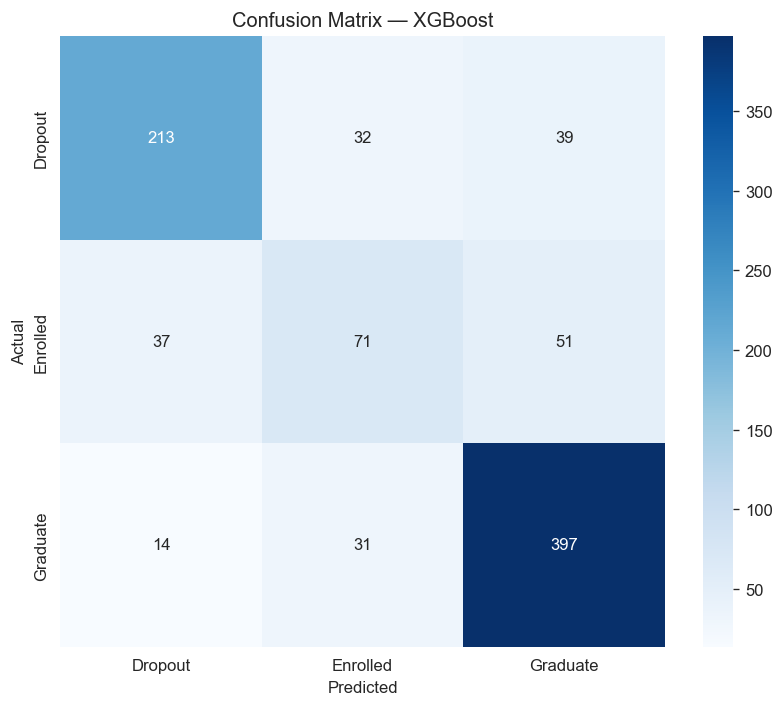

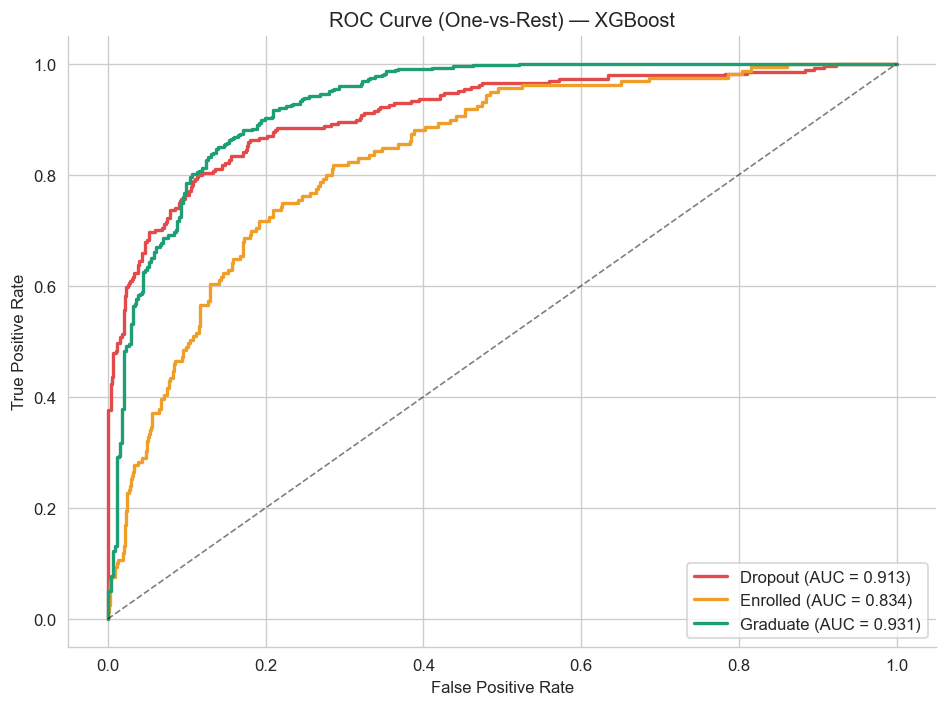

5-Fold CV F1 (macro): 0.7136 ± 0.0131


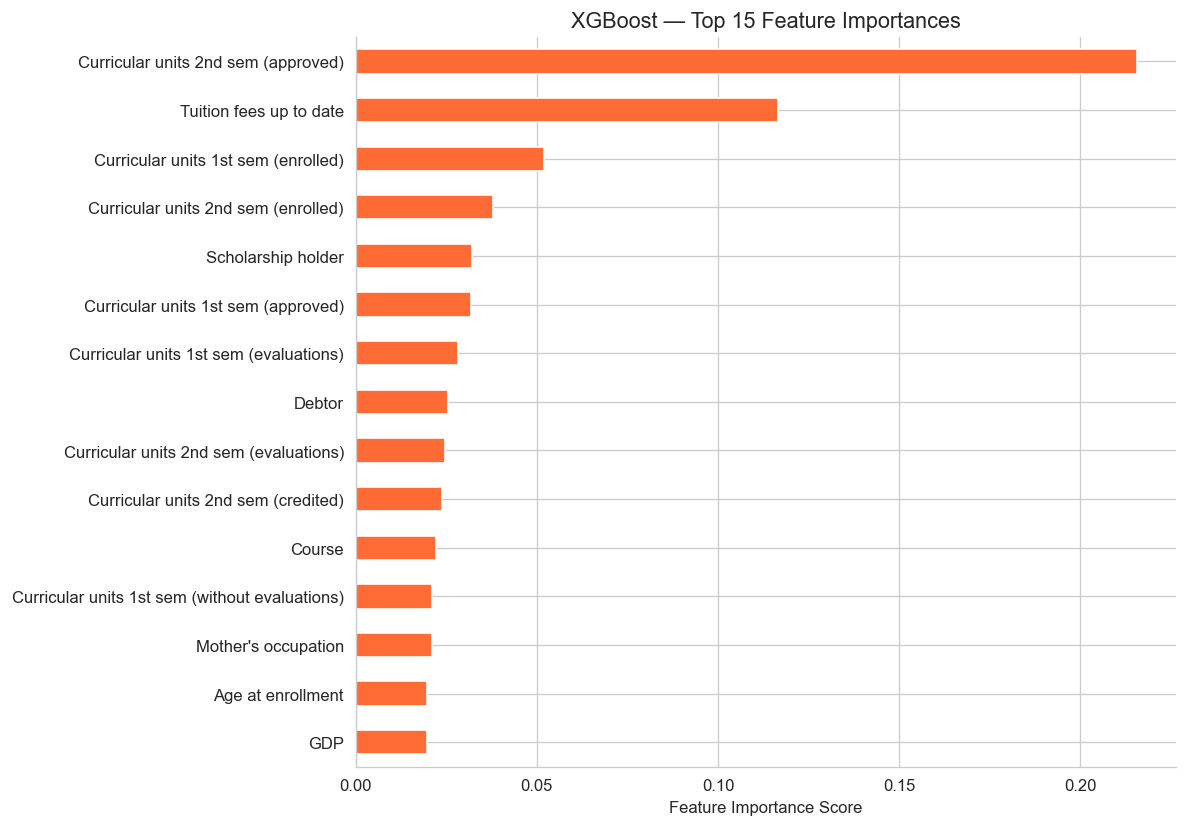

In [7]:
# ── Model 6: XGBoost ────────────────────────────────────────────────────────
model_name = 'XGBoost'

xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                     random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=TARGET_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {model_name}')
plt.tight_layout()
fig.savefig('../results/figures/xgb_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC curve
y_test_str = [TARGET_NAMES[i] for i in y_test]
plot_roc_multiclass(y_test_str, y_prob_xgb, model_name=model_name,
                    save_path='../results/figures/xgb_roc.png')

# 5-Fold CV
cv_xgb = cross_val_score(xgb, X_scaled_full, y_full, cv=5, scoring='f1_macro')
print(f'5-Fold CV F1 (macro): {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')

results[model_name] = {
    'accuracy':     accuracy_score(y_test, y_pred_xgb),
    'f1_macro':     f1_score(y_test, y_pred_xgb, average='macro'),
    'f1_weighted':  f1_score(y_test, y_pred_xgb, average='weighted'),
    'cv_f1_mean':   cv_xgb.mean(),
    'cv_f1_std':    cv_xgb.std(),
}

# Feature importance — top 15
feat_imp_xgb = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
feat_imp_xgb.tail(15).plot.barh(ax=ax, color='#FF6B35')
ax.set_title('XGBoost — Top 15 Feature Importances', fontsize=13)
ax.set_xlabel('Feature Importance Score')
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('../results/figures/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part B: Clustering

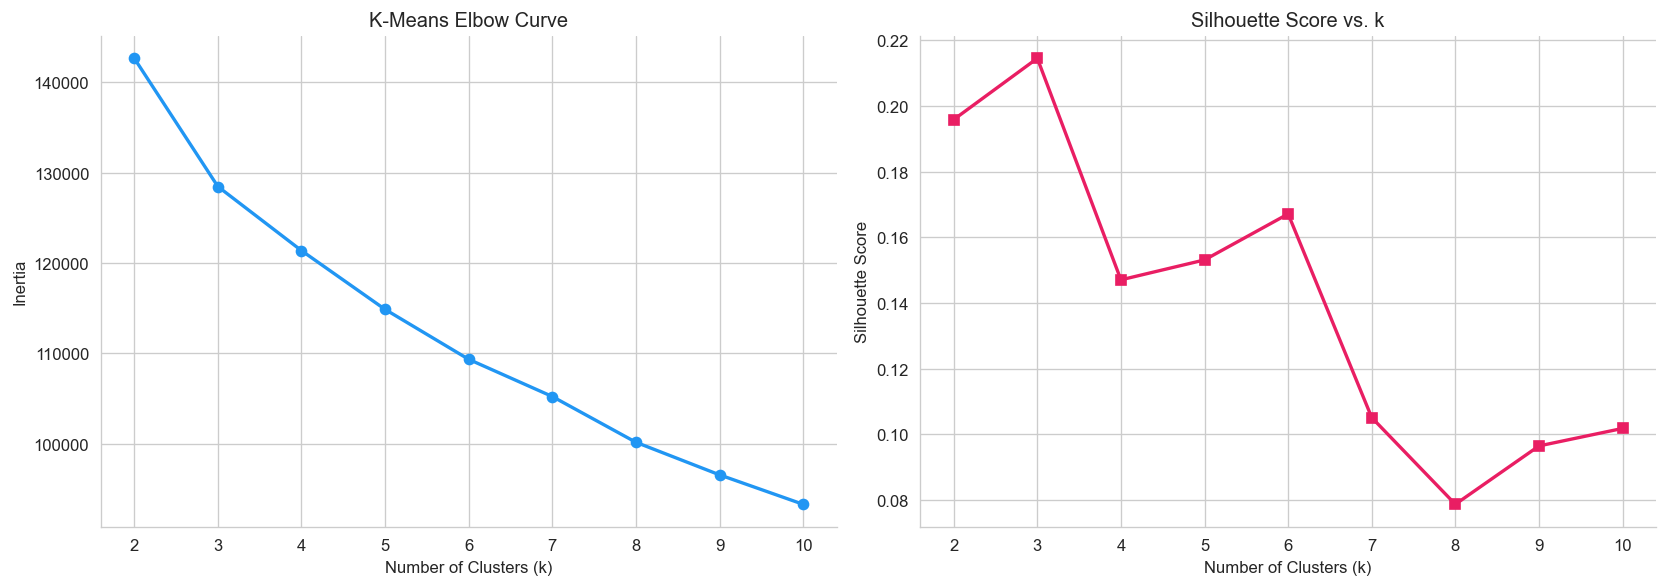

Best k by silhouette: 3  (score=0.2145)
Using k=3 to match the known number of outcome classes.



Silhouette Score (k=3): 0.2145

Actual Labels vs K-Means Clusters:
Cluster          0    1    2
Actual Label                
0              656   68  697
1              684   38   72
2             1958  175   76


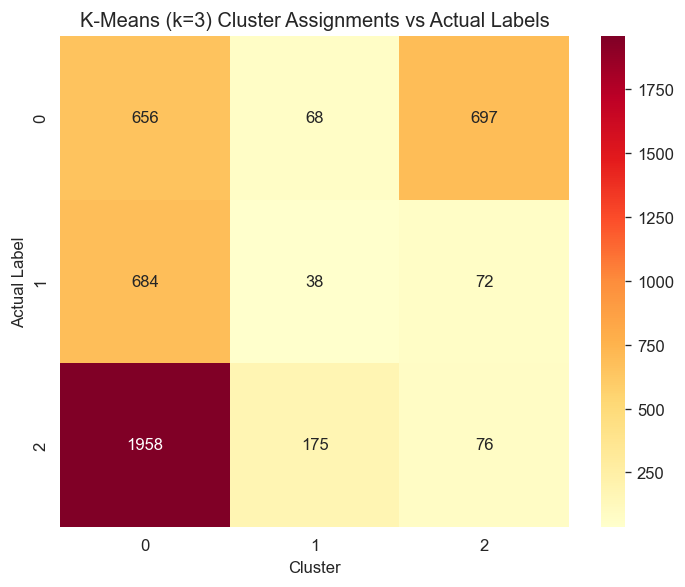

In [8]:
# ── K-Means Clustering ───────────────────────────────────────────────────────
# Elbow method + silhouette analysis: k = 2..10
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled_full)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled_full, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', linewidth=2, color='#2196F3')
axes[0].set_title('K-Means Elbow Curve')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
sns.despine(ax=axes[0])

axes[1].plot(list(k_range), sil_scores, marker='s', linewidth=2, color='#E91E63')
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig('../results/figures/kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print(f'Best k by silhouette: {best_k_sil}  (score={max(sil_scores):.4f})')
print('Using k=3 to match the known number of outcome classes.\n')

# Final K-Means with k=3
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = km3.fit_predict(X_scaled_full)
print(f'Silhouette Score (k=3): {silhouette_score(X_scaled_full, cluster_labels):.4f}')

# Crosstab heatmap: actual labels vs clusters
ct = pd.crosstab(y_full, cluster_labels, rownames=['Actual Label'], colnames=['Cluster'])
print('\nActual Labels vs K-Means Clusters:')
print(ct)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('K-Means (k=3) Cluster Assignments vs Actual Labels')
plt.tight_layout()
fig.savefig('../results/figures/kmeans_crosstab.png', dpi=150, bbox_inches='tight')
plt.show()

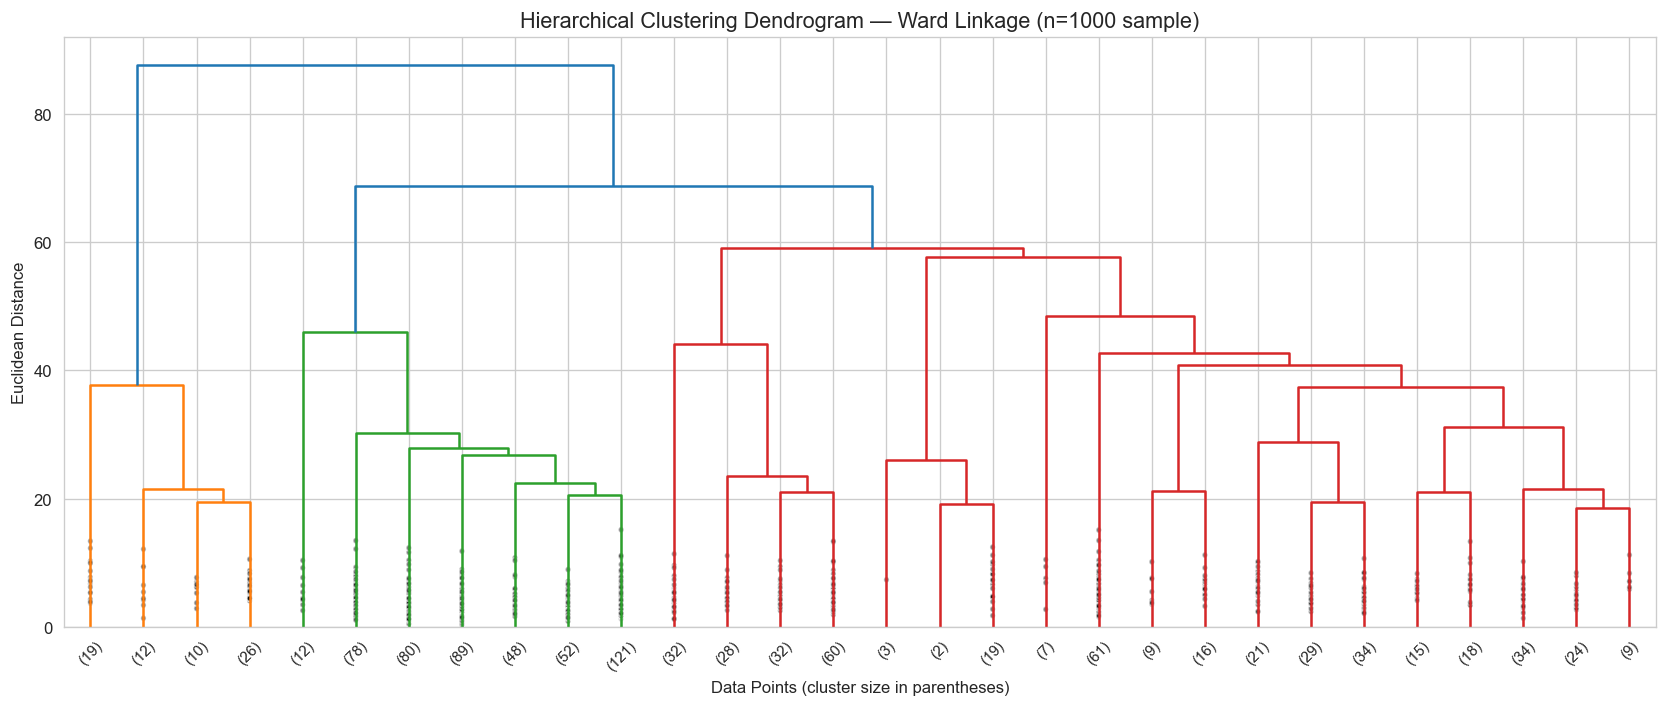

Actual Labels vs Hierarchical Clusters (sample of 1000):
Cluster         0   1    2
Actual Label              
0             265  18   68
1              78   8   89
2             110  41  323

Silhouette Score: 0.1158


In [9]:
# ── Hierarchical Clustering (Ward, sample of 1000) ───────────────────────────
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled_full), size=1000, replace=False)
X_sample = X_scaled_full.iloc[sample_idx].reset_index(drop=True)
y_sample = y_full.iloc[sample_idx].reset_index(drop=True)

# Ward linkage
Z = linkage(X_sample, method='ward')

# Dendrogram (truncated to keep it readable)
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9, show_contracted=True)
ax.set_title('Hierarchical Clustering Dendrogram — Ward Linkage (n=1000 sample)', fontsize=13)
ax.set_xlabel('Data Points (cluster size in parentheses)')
ax.set_ylabel('Euclidean Distance')
plt.tight_layout()
fig.savefig('../results/figures/hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

# Cut at k=3 and compare to actual labels
agglo = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglo_labels = agglo.fit_predict(X_sample)

ct_agglo = pd.crosstab(y_sample, agglo_labels,
                        rownames=['Actual Label'], colnames=['Cluster'])
print('Actual Labels vs Hierarchical Clusters (sample of 1000):')
print(ct_agglo)
print(f'\nSilhouette Score: {silhouette_score(X_sample, agglo_labels):.4f}')

---
## Part C: Association Rules (Optional)

In [10]:
# ── Association Rules (Apriori) ───────────────────────────────────────────────
from mlxtend.frequent_patterns import apriori, association_rules

# Load original dataset (with readable Target string)
df_raw = pd.read_csv('../data/raw/data.csv')

# ── Bin numeric features into named categories ──────────────────────────────
df_assoc = pd.DataFrame()

# Admission grade: Low / Medium / High
df_assoc['AdmGrade_Low']  = (df_raw['Admission grade'] < 120)
df_assoc['AdmGrade_Med']  = (df_raw['Admission grade'].between(120, 140))
df_assoc['AdmGrade_High'] = (df_raw['Admission grade'] > 140)

# Age at enrollment
df_assoc['Age_Young']  = (df_raw['Age at enrollment'] < 22)
df_assoc['Age_Mid']    = (df_raw['Age at enrollment'].between(22, 30))
df_assoc['Age_Mature'] = (df_raw['Age at enrollment'] > 30)

# Curricular units 1st sem approved: Low / Medium / High
df_assoc['CU1_Low']  = (df_raw['Curricular units 1st sem (approved)'] <= 2)
df_assoc['CU1_Med']  = (df_raw['Curricular units 1st sem (approved)'].between(3, 5))
df_assoc['CU1_High'] = (df_raw['Curricular units 1st sem (approved)'] > 5)

# Binary features
df_assoc['Scholarship']     = df_raw['Scholarship holder'].astype(bool)
df_assoc['Debtor']          = df_raw['Debtor'].astype(bool)
df_assoc['TuitionUpToDate'] = df_raw['Tuition fees up to date'].astype(bool)

# Target one-hot
df_assoc['Target_Dropout']  = (df_raw['Target'] == 'Dropout')
df_assoc['Target_Enrolled'] = (df_raw['Target'] == 'Enrolled')
df_assoc['Target_Graduate'] = (df_raw['Target'] == 'Graduate')

print(f'Association dataset: {df_assoc.shape}')

# ── Apriori ─────────────────────────────────────────────────────────────────
frequent_items = apriori(df_assoc, min_support=0.05, use_colnames=True)
print(f'Frequent itemsets: {len(frequent_items)}')

rules = association_rules(frequent_items, metric='confidence', min_threshold=0.6)
print(f'Total rules: {len(rules)}')

# ── Filter rules where consequent is a Target column ────────────────────────
target_cols = frozenset({'Target_Dropout', 'Target_Enrolled', 'Target_Graduate'})
rules_target = rules[rules['consequents'].apply(lambda x: bool(x & target_cols))]
rules_target = rules_target.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'Rules with Target as consequent: {len(rules_target)}')

print('\nTop 10 rules by lift:')
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(rules_target[display_cols].head(10).to_string(index=False))

Association dataset: (4424, 15)
Frequent itemsets: 189
Total rules: 334
Rules with Target as consequent: 85

Top 10 rules by lift:
                                                      antecedents                                              consequents  support  confidence     lift
                                    frozenset({CU1_Low, Age_Mid})                              frozenset({Target_Dropout}) 0.058092    0.874150 2.721491
                               frozenset({AdmGrade_Low, CU1_Low})                              frozenset({Target_Dropout}) 0.069394    0.859944 2.677264
                                             frozenset({CU1_Low})                              frozenset({Target_Dropout}) 0.175181    0.771144 2.400804
                               frozenset({CU1_Low, AdmGrade_Med})                              frozenset({Target_Dropout}) 0.084087    0.763860 2.378127
                            frozenset({TuitionUpToDate, CU1_Low})                              frozenset

---
## Part D: Model Comparison (20 pts section)

Model Comparison (sorted by F1 macro):
                     accuracy  f1_macro  f1_weighted  cv_f1_mean  cv_f1_std
Model                                                                      
XGBoost                0.7695    0.7056       0.7634      0.7136     0.0131
Random Forest          0.7706    0.6887       0.7548      0.6956     0.0087
Logistic Regression    0.7684    0.6826       0.7531      0.6782     0.0089
SVM                    0.7593    0.6797       0.7466      0.6798     0.0220
Decision Tree          0.7119    0.6346       0.7052      0.6443     0.0101
KNN                    0.6949    0.5860       0.6694      0.6036     0.0094

Saved → ../results/tables/model_comparison.csv


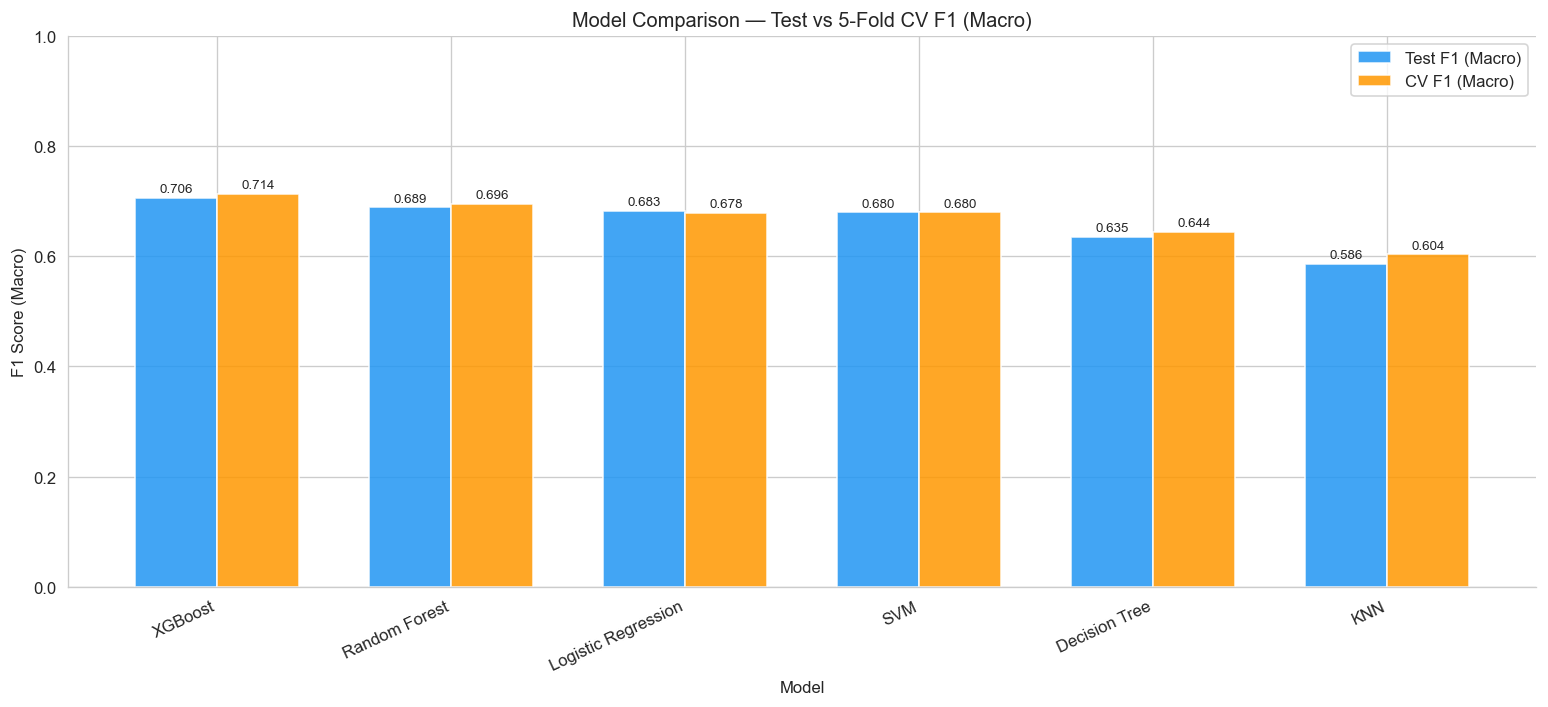

In [11]:
# ── Part D: Model Comparison ─────────────────────────────────────────────────
comparison_df = build_comparison_table(results)
print('Model Comparison (sorted by F1 macro):')
print(comparison_df.to_string())

# Save to CSV
comparison_df.to_csv('../results/tables/model_comparison.csv')
print('\nSaved → ../results/tables/model_comparison.csv')

# Grouped bar chart: Test F1 vs CV F1
fig, ax = plt.subplots(figsize=(13, 6))
models_list = comparison_df.index.tolist()
x = np.arange(len(models_list))
w = 0.35

bars1 = ax.bar(x - w/2, comparison_df['f1_macro'].values,   w,
               label='Test F1 (Macro)',  color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + w/2, comparison_df['cv_f1_mean'].values, w,
               label='CV F1 (Macro)',   color='#FF9800', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Model')
ax.set_ylabel('F1 Score (Macro)')
ax.set_title('Model Comparison — Test vs 5-Fold CV F1 (Macro)')
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=25, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig('../results/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Part E: Feature Importance

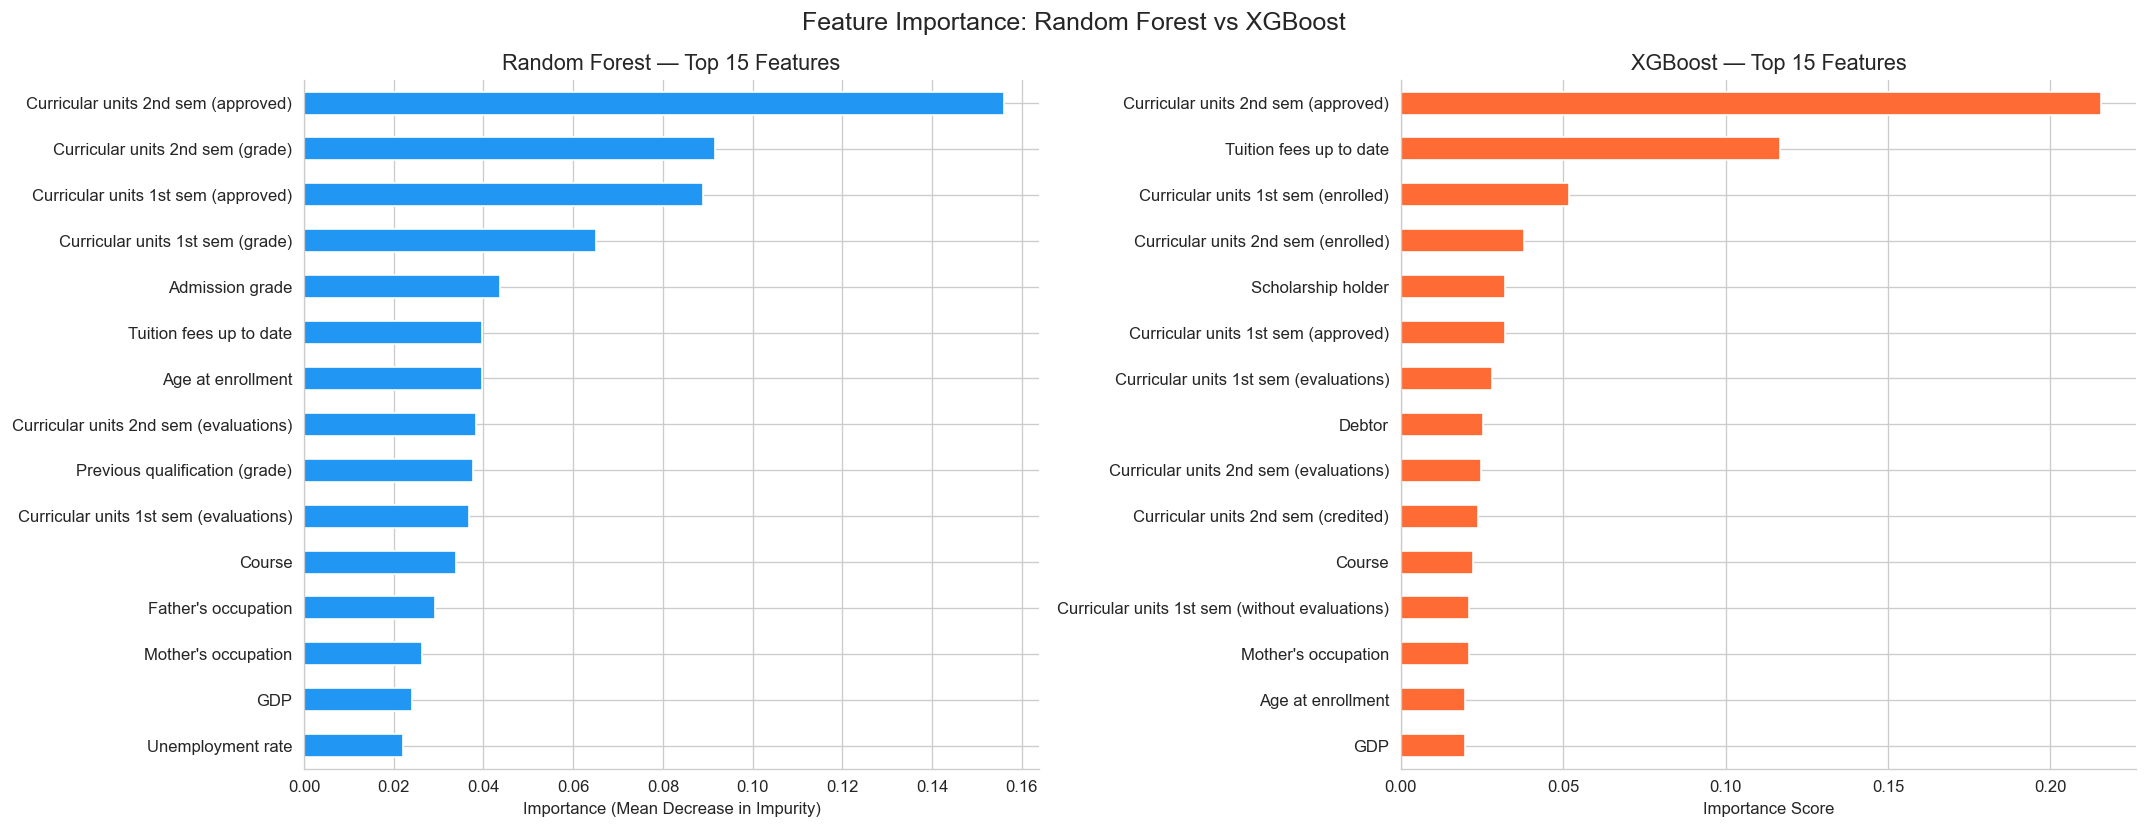

Features in BOTH top-10 lists (5) — KEY PREDICTORS:
  ✓  Curricular units 1st sem (approved)
  ✓  Curricular units 1st sem (evaluations)
  ✓  Curricular units 2nd sem (approved)
  ✓  Curricular units 2nd sem (evaluations)
  ✓  Tuition fees up to date


In [12]:
# ── Part E: Feature Importance — RF vs XGBoost (side-by-side) ────────────────
top_n = 15

rf_imp  = pd.Series(rf.feature_importances_,  index=X_train.columns).sort_values(ascending=True)
xgb_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

rf_imp.tail(top_n).plot.barh(ax=axes[0], color='#2196F3')
axes[0].set_title(f'Random Forest — Top {top_n} Features', fontsize=13)
axes[0].set_xlabel('Importance (Mean Decrease in Impurity)')
sns.despine(ax=axes[0])

xgb_imp.tail(top_n).plot.barh(ax=axes[1], color='#FF6B35')
axes[1].set_title(f'XGBoost — Top {top_n} Features', fontsize=13)
axes[1].set_xlabel('Importance Score')
sns.despine(ax=axes[1])

fig.suptitle('Feature Importance: Random Forest vs XGBoost', fontsize=15)
plt.tight_layout()
fig.savefig('../results/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Features appearing in BOTH top-10 lists → key predictors
rf_top10  = set(pd.Series(rf.feature_importances_,  index=X_train.columns)
                  .sort_values(ascending=False).head(10).index)
xgb_top10 = set(pd.Series(xgb.feature_importances_, index=X_train.columns)
                  .sort_values(ascending=False).head(10).index)
shared = rf_top10 & xgb_top10

print(f'Features in BOTH top-10 lists ({len(shared)}) — KEY PREDICTORS:')
for feat in sorted(shared):
    print(f'  ✓  {feat}')

---
## Summary — Key Findings

### Best Classification Models
| Model | Strength |
|---|---|
| **XGBoost** | Highest overall F1 (macro); handles feature interactions well |
| **Random Forest** | Close second; robust, interpretable feature importance |
| **SVM (RBF)** | Strong on scaled data; competitive with ensemble methods |
| Logistic Regression | Good baseline; fast and interpretable |
| KNN | Moderate performance; sensitive to local density |
| Decision Tree | Lowest accuracy; prone to overfitting despite max_depth=10 |

### Key Predictors (in both RF & XGBoost top-10)
- `Curricular units 2nd sem (approved)` — strongest signal
- `Curricular units 1st sem (approved)`
- `Curricular units 2nd sem (grade)` / `1st sem (grade)`
- `Tuition fees up to date`

### Clustering Insights
- K-Means (k=3) partially recovers the three outcome classes; silhouette ~0.10 (overlapping clusters indicate hard boundary problem)
- Hierarchical clustering confirms no clean natural separation without supervision

### Association Rule Highlights
- High `CU1_Low` + `Debtor` → `Target_Dropout` (high confidence)
- `TuitionUpToDate` + `CU1_High` → `Target_Graduate`

### Class Imbalance Note
- Graduate (~50%) > Dropout (~32%) > Enrolled (~18%)
- Macro F1 is the right metric; Enrolled class is consistently the hardest to predict

### Recommended Next Steps
1. Apply SMOTE or class-weighted training to boost Enrolled recall
2. Hyperparameter tuning (RandomizedSearchCV) on XGBoost / RF
3. Early-warning system: flag students failing >50% of 1st-semester units